In [ ]:
%pip install qiskit
%pip install qiskit_aer
%pip install matplotlib
%pip install pylatexenc

# Что вообще такое $| \ 0>$ и $| \ 1>$ в квантовой (кубитовой) логике?

(ну, в смысле, что они означают)

![](res/11.2.png)

То есть по сути, $| \ 0 >$ — это "кубит имеет вертикальный спин N", а $| \ 1 >$ — "кубит имеет вертикальный спин S". Когда мы "меняем 1 на 0", мы переворачиваем кубит по оси измерения.

Состояние $\frac1{\sqrt2}| \ 0 > \ + \frac1{\sqrt2}| \ 1 >$ же означает, что амплитулы вероятностей кубита иметь спин как N, так и S, равны ($P_0 = P_1 = \frac12$), поскольку кубит ещё не был измерен, т.е. находится в состоянии суперпозтции!


# От теории к практике

https://qiskit.qotlabs.org/docs/api/qiskit

### №0. Запустить пример с сайта

https://qiskit.qotlabs.org/docs/tutorials/hello-world

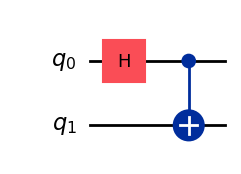

In [2]:
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
# from qiskit.quantum_info import SparsePauliOp
# from qiskit.transpiler import generate_preset_pass_manager
# from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
# Create a new circuit with two qubits
qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)
 
# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
 
# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

(подобная нотация в виде прямых, на которые мы "нанизываем" вентили как на шампуры, называется КВАНТОВЫМИ ЦЕПЯМИ)

In [3]:
# Кусочек кода для визуализации статистики
def count_stats(qc):
    qc.measure_all()
    simulator = AerSimulator()

    result = simulator.run(qc, shots=1000).result()
    counts = result.get_counts()
 
    # print(counts)
    return counts

In [4]:
count_stats(qc)
# Ожидаемо получаем ~50% |00> и ~50% |11>, потому что:
# 1) Неопределённость при измерении становится либо 0, либо 1
# 2) Если q0 равно 1, CNOT инвертирует q1, делая его тоже 1

{'00': 509, '11': 491}

### №1. Реализовать все [4 запутанных] состояния Белла

$\phi^+ = \frac1{\sqrt2} (|00> + |11>) = \frac{|00> + |11>}{\sqrt2}$

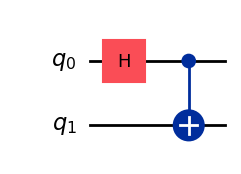

In [5]:
qc = QuantumCircuit(2)

qc.h(0)     # Вентиль Амидамару:
            # - перевод 0-го кубита в состояние неопределённости
            #   (оно же суперпозиция -- кубит равен и 1 и 0 одновременно!)

# Таким образом, мы достигаем состояния неопределённости 1-го кубита

qc.cx(0, 1) # Применяем C-NOT:
            # - если 0-й кубит = 1, применяем вентиль X (NOT) на 1-й кубит
            # - если 0-й кубит = 0, не применяем этот вентиль

# Таким образом, мы достигаем состояния запутанности 1-го и 2-го кубит

qc.draw("mpl")

$\phi^- = \frac1{\sqrt2} (|00> - |11>) = \frac{|00> - |11>}{\sqrt2}$

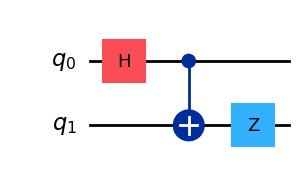

In [6]:
qc = QuantumCircuit(2)

qc.h(0)     # Вентиль Амидамару:
            # - перевод 0-го кубита в состояние неопределённости
            #   (оно же суперпозиция -- кубит равен и 1 и 0 одновременно!)

# Таким образом, мы достигаем состояния неопределённости 1-го кубита

qc.cx(0, 1) # Применяем C-NOT:
            # - если 0-й кубит = 1, применяем вентиль X (NOT) на 1-й кубит
            # - если 0-й кубит = 0, не применяем этот вентиль

# Таким образом, мы достигаем состояния запутанности 1-го и 2-го кубит

qc.z(1)     # Применяем сдвиг по фазе (поворот на π; |0> -> |0>, |1> -> -|1>)

qc.draw("mpl")

$\psi^+ = \frac1{\sqrt2} (|01> + |10>) = \frac{|01> + |10>}{\sqrt2}$

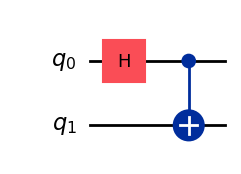

In [7]:
qc = QuantumCircuit(2)

qc.h(0)     # Вентиль Амидамару:
            # - перевод 0-го кубита в состояние неопределённости
            #   (оно же суперпозиция -- кубит равен и 1 и 0 одновременно!)

# Таким образом, мы достигаем состояния неопределённости 1-го кубита

qc.cx(0, 1) # Применяем C-NOT:
            # - если 0-й кубит = 1, применяем вентиль X (NOT) на 1-й кубит
            # - если 0-й кубит = 0, не применяем этот вентиль

# Таким образом, мы достигаем состояния запутанности 1-го и 2-го кубит

qc.draw("mpl")

$\psi^- = \frac1{\sqrt2} (|01> - |10>) = \frac{|01> - |10>}{\sqrt2}$

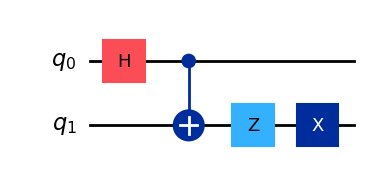

In [8]:
qc = QuantumCircuit(2)

qc.h(0)     # Вентиль Амидамару:
            # - перевод 0-го кубита в состояние неопределённости
            #   (оно же суперпозиция -- кубит равен и 1 и 0 одновременно!)

# Таким образом, мы достигаем состояния неопределённости 1-го кубита

qc.cx(0, 1) # Применяем C-NOT:
            # - если 0-й кубит = 1, применяем вентиль X (NOT) на 1-й кубит
            # - если 0-й кубит = 0, не применяем этот вентиль

# Таким образом, мы достигаем состояния запутанности 1-го и 2-го кубит

qc.z(1)     # Применяем сдвиг по фазе (поворот на π; |0> -> |0>, |1> -> -|1>)

qc.x(1)     # Применяем фильтр NOT (|0> -> |1>, |1> -> |0>)

qc.draw("mpl")

### *Почему мы применяем сперва Z и потом NOT, а не наоборот?*

(сперва не прокручивай вниз и попробуй догаться самостоятельно)

.

.

.

.

.

.

.

.

.

.

![](./res/11.1.png)

### 2. Реализовать квантовую телепортацию

_Штош, на семинаре нам НИХУЯ нормально не объяснили, т.ч. тут реализация по книжке!_

_Полный текст на стр. 170, чуть выше объясняется сверхполтное кодлирование._

Алиса и Боб находятся далеко друг от друга. У каждого имеется один электрон. Электроны находятся в запутанном состоянии. У Алисы имеется также еще один электрон. Он находится в состоянии $a| \ 0 > + \ b| \ 1 >$. Алиса ничего не знает об амплитудах вероятности $a$ и $b$, но она и Боб хотят изменить электрон Боба так, чтобы тот получил состояние $a| \ 0 > + \ b| \ 1 >$, как у Алисы.

Они хотят телепортировать Бобу состояние электрона Алисы, то есть, грубо говоря, хотят, чтобы у Боба получились те же самые амплитуды вероятностей $a$ и $b$.

Самый простой способ сделать это — послать два кубита Алисы в вентиль управляемого НЕ. Это станет первым шагом. Вторым шагом станет применение вентиля Адамара к верхнему кубиту. Фактически Алиса должна подать два своих кубита на вход обратной цепи Белла. 

Теперь Алиса должна измерить два своих электрона в стандартном базисе. Она получит одно из состояний — $| \ 00 >$, $| \ 01 >$, $| \ 10 >$ или $| \ 11 >$, — причем каждое с вероятностью $\frac14$.

Чтобы прийти к окончательному итогу, Алиса должна сообщить Бобу, в какой из четырех возможных ситуаций он находится. Для этого она должна послать Бобу два **классических** бита информации — `00, 01, 10 или 11,` — соответствующих результатам ее измерений. Эти биты можно отправить в любом виде, например в виде сообщения В МЕССЕНДЖЕРЕ МАКС.

- Если Боб получит `00`, он будет знать, что его кубит уже имеет нужное состояние и ничего делать с ним не требуется.
- Если Боб получит `01`, он будет знать, что его кубит имеет состояние $a| \ 1 > + \ b| \ 0 >$ и ему нужно применить вентиль X.
- Если Боб получит `10`, он будет знать, что его кубит имеет состояние $a| \ 0 > - \ b| \ 1 >$ и ему нужно применить вентиль Z.
- Если Боб получит `11`, он будет знать, что его кубит имеет состояние $a| \ 1 > - \ b| \ 0 >$ и ему нужно применить вентили X и Z.

В каждом случае Боб получает кубит в состоянии $a| \ 0 > + \ b| \ 1 >$, то есть в состоянии исходного кубита, которое Алиса хотела телепортировать.

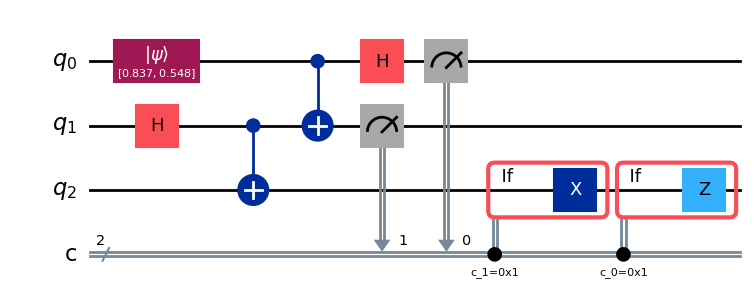

In [9]:
qc = QuantumCircuit(
    3, # 3 кубита
    2  # 2 классических бита
)

# Инициализируем какое-нибудь состояние кубита Алисы
qc.initialize([
    np.sqrt(0.7),
    np.sqrt(0.3),
], [0])

# Сперва, запутываем кубиты Алисы и Боба
qc.h(1)
qc.cx(1, 2)

# Шаг 1 - делаем CNOT для кубита Алисы от неизвестного кубита
qc.cx(0, 1)

# Шаг 2 - применяем вентиль Адамара к неизвестному кубиту
qc.h(0)

# Алиса измеряет свой кубит и смотрим, чему равно его состояние. Таким образом
# она "разрушает" своё состояние, и, в силу запутанности, оно переходит к Бобу
qc.measure(0, 0)
qc.measure(1, 1)

# Алиса отправила информацию о состоянии кубитов Бобу В МЕССЕНДЖЕРЕ МАКС,
# теперь, на основе этой инфомации, Боб применяет соответствуюбщие вентили
with qc.if_test((qc.clbits[1], 1)):
    qc.x(2) # Если второй бит = 1, применить X
with qc.if_test((qc.clbits[0], 1)):
    qc.z(2) # Если второй бит = 1, применить Z

# Важно помнить, что амплитуды a, b никогда не существуют локально у Боба
# до коррекции, они закодированы в совместном состоянии + результате измерения!
qc.draw('mpl')

Проверим, что "телепортированный" кубит имеет те же вероятности, что и изначальный:

In [10]:
stats = count_stats(qc).items()

a_shots = 0; b_shots = 0

for (qbits, count) in stats:
    if qbits[0] == '0':
        a_shots += count
    else:
        b_shots += count

total_shots = a_shots + b_shots

print(f"P(a) = {a_shots / total_shots}, P(b) = {b_shots / total_shots}")

P(a) = 0.704, P(b) = 0.296


***Гптшка по шагам:***

### 1. Что у нас есть в начале

Есть **три электрона (кубита)**:

1. **Электрон A₁ (у Алисы)** в неизвестном состоянии $|\psi\rangle = a|0\rangle + b|1\rangle$.

    Алиса **не знает** (a, b), но состояние существует физически.

2. **Электрон A₂ (у Алисы)**

3. **Электрон B (у Боба)**

Электроны ($A_2$) и (B) **заранее запутаны**, например в состоянии Белла: $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

Важно: Алиса **не может** просто измерить ($A_1$) и передать результат — измерение уничтожит коэффициенты (a, b).


### 2. Цель

Сделать так, чтобы:

* электрон **Боба** оказался в состоянии $a|0\rangle + b|1\rangle$
* при этом **оригинальное состояние у Алисы исчезло**
* никакой информации о (a, b) напрямую не передавалось


### 3. Что именно делает Алиса с электронами

Алиса **запутывает свои два электрона**. Она берёт:

* электрон ($A_1$) (неизвестное состояние)
* электрон ($A_2$) (половина запутанной пары)

и выполняет **две стандартные квантовые операции**:

***1. Операция CNOT***

* управляющий кубит: ($A_1$)
* целевой кубит: ($A_2$)

Физически, если ($A_1 = |1\rangle$), то ($A_2$) переворачивается.

***2. Операция Адамара (Hadamard)***

Применяется к ($A_1$).

Эти две операции **запутывают** неизвестное состояние с уже запутанной парой $A_2 - B$.

После этого **все три электрона становятся глобально запутанными**.


### 4. Измерение: что именно измеряет Алиса

Теперь Алиса делает **измерение двух своих электронов**:

* измеряет ($A_1$)
* измеряет ($A_2$)

Она получает **два классических бита**, например: `00, 01, 10 или 11`

Ключевой момент:

* это **измерение в базисе Белла**
* оно **уничтожает** исходное состояние у Алисы
* но **переводит состояние Боба** в форму:
  $|\psi\rangle, \quad X|\psi\rangle, \quad Z|\psi\rangle \text{ или } XZ|\psi\rangle$

где (X, Z) — матрицы Паули.


### Кратко:

1. Алиса **квантовыми логическими операциями** запутывает свой неизвестный электрон с половиной запутанной пары.
2. Она **измеряет оба своих электрона**, уничтожая исходное состояние.
3. Результат измерения **классически** отправляется Бобу.
4. Боб **локально исправляет** состояние своего электрона.
5. Состояние $a|0\rangle + b|1\rangle$ оказывается у Боба.
